# Baseball
## Interests: 
- Pitch evolution
- Pitch visualizations
- Hitting evolution
### Data
Data from pybaseball API

## Example
[https://github.com/jldbc/pybaseball/blob/master/EXAMPLES/strikeouts_on_the_rise.ipynb](https://github.com/jldbc/pybaseball/blob/master/EXAMPLES/strikeouts_on_the_rise.ipynb)

In [1]:
from pybaseball import team_pitching 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
pitching_data = team_pitching(1900,2025)

In [3]:
print(("data shape: {}").format(pitching_data.shape)) # found typo in example pretty good lol
print(pitching_data.head())

data shape: (3073, 392)
   teamIDfg  Season Team  Age    W   L   ERA    G   GS   CG  ...  Pit+ FC  \
0        17    1907  CHC   28  107  44  1.73  200  155  114  ...      NaN   
1        17    1909  CHC   26  104  49  1.74  212  155  111  ...      NaN   
2        17    1906  CHC   27  115  36  1.75  187  154  125  ...      NaN   
3        10    1910  PHA   26  102  48  1.79  200  155  123  ...      NaN   
4        10    1909  PHA   26   95  58  1.93  214  153  110  ...      NaN   

   Stf+ FS  Loc+ FS  Pit+ FS  Stuff+  Location+  Pitching+  Stf+ FO  Loc+ FO  \
0      NaN      NaN      NaN     NaN        NaN        NaN      NaN      NaN   
1      NaN      NaN      NaN     NaN        NaN        NaN      NaN      NaN   
2      NaN      NaN      NaN     NaN        NaN        NaN      NaN      NaN   
3      NaN      NaN      NaN     NaN        NaN        NaN      NaN      NaN   
4      NaN      NaN      NaN     NaN        NaN        NaN      NaN      NaN   

   Pit+ FO  
0      NaN  
1     

In [4]:
pitching_data.describe()

,teamIDfg,Season,Age,W,L,ERA,G,GS,CG,ShO,...,Pit+ FC,Stf+ FS,Loc+ FS,Pit+ FS,Stuff+,Location+,Pitching+,Stf+ FO,Loc+ FO,Pit+ FO
count,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,3073.000000,...,180.000000,169.000000,169.000000,169.000000,180.000000,180.000000,180.000000,7.000000,7.000000,7.000000
mean,145.374553,1967.509600,27.747478,71.422714,71.269118,3.963775,395.116499,143.289945,37.160104,6.258054,...,101.838889,102.828402,94.644970,95.828402,100.111111,99.944444,100.061111,109.571429,80.142857,85.142857
std,358.573045,36.142531,1.567081,22.919909,22.874619,0.843962,190.487659,38.816302,33.566589,5.447858,...,6.280380,12.087485,18.775728,19.798993,3.682798,1.774186,4.157733,13.914706,49.744107,52.809180
min,1.000000,1900.000000,22.000000,0.000000,1.000000,1.730000,2.000000,1.000000,0.000000,0.000000,...,81.000000,73.000000,-112.000000,-86.000000,90.000000,96.000000,89.000000,88.000000,-28.000000,-28.000000
25%,8.000000,1936.000000,27.000000,64.000000,64.000000,3.470000,266.000000,154.000000,7.000000,2.000000,...,98.000000,95.000000,91.000000,89.000000,98.000000,99.000000,97.000000,102.000000,83.500000,89.000000
50%,17.000000,1971.000000,28.000000,76.000000,75.000000,3.920000,386.000000,161.000000,29.000000,5.000000,...,101.000000,102.000000,98.000000,98.000000,100.000000,100.000000,100.000000,114.000000,94.000000,99.000000
75%,27.000000,2000.000000,29.000000,87.000000,86.000000,4.400000,562.000000,162.000000,61.000000,10.000000,...,106.000000,111.000000,103.000000,106.000000,102.250000,101.000000,103.000000,117.500000,101.500000,105.000000
max,1180.000000,2025.000000,37.000000,116.000000,121.000000,21.000000,794.000000,165.000000,148.000000,32.000000,...,123.000000,151.000000,120.000000,134.000000,113.000000,105.000000,112.000000,126.000000,125.000000,137.000000


In [5]:
league_average = pitching_data.groupby('Season', as_index=False)['K/9'].mean() # group on season for K/9 and averaging

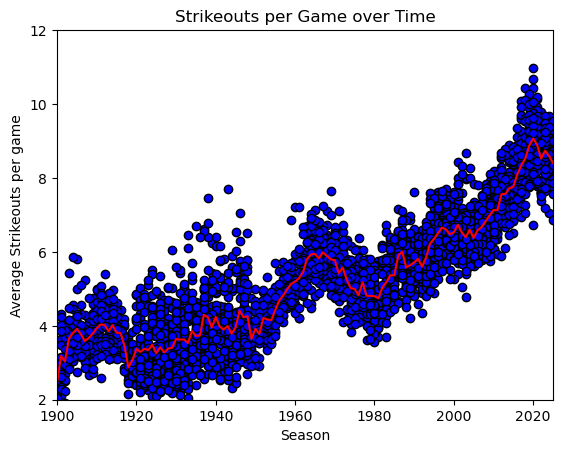

In [6]:
plt.scatter(pitching_data['Season'], pitching_data['K/9'], c='blue', ec='black')
plt.plot(league_average['Season'], league_average['K/9'], c='red')
plt.xlim(1900,2025)
plt.ylim(2,12)
plt.xlabel('Season')
plt.ylabel('Average Strikeouts per game')
plt.title('Strikeouts per Game over Time');
plt.show()

# New science of hitting example 
[https://github.com/jldbc/pybaseball/blob/master/EXAMPLES/fivethirtyeight_new_science_of_hitting.ipynb](https://github.com/jldbc/pybaseball/blob/master/EXAMPLES/fivethirtyeight_new_science_of_hitting.ipynb)

In [7]:
#imports
from pybaseball import statcast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [8]:
# statcast data on all pitches from time frame
data = statcast('2017-05-01', '2017-06-30')
print(data.shape)

This is a large query, it may take a moment to complete


100%|██████████████████████████████████████████████████████████████████████████████████| 61/61 [00:16<00:00,  3.65it/s]


(247710, 118)


In [9]:
data2 = data.dropna(subset=['launch_angle', 'launch_speed','estimated_ba_using_speedangle'])

In [10]:
data2.shape

(43130, 118)

In [11]:
data2["launch_speed"] = data2["launch_speed"].astype(float) # apparently there are data type errors in original example 
data2["launch_angle"] = data2["launch_angle"].astype(float)
data2["estimated_ba_using_speedangle"] = data2["estimated_ba_using_speedangle"].astype(float)

<Figure size 800x800 with 0 Axes>

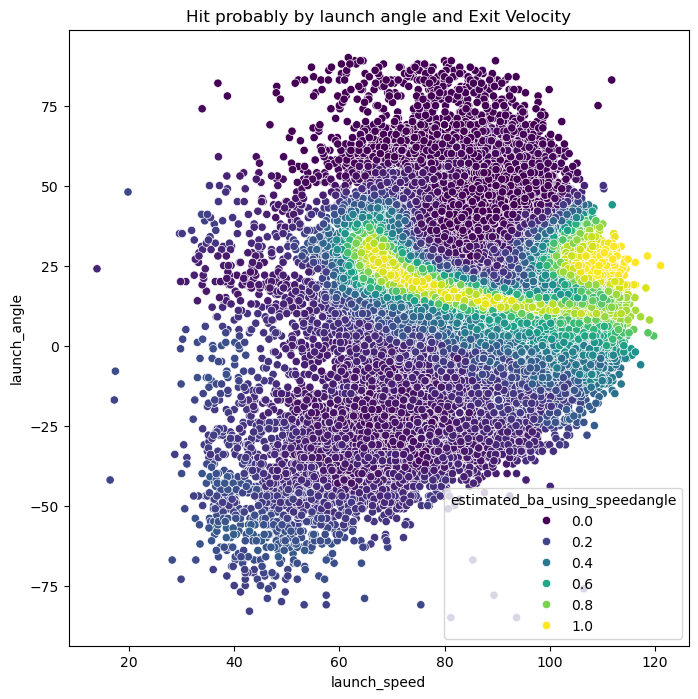

In [13]:
plt.figure(figsize=(8,8)) # example was just wrong
sns.despine(left=True, bottom=True)
sns.scatterplot(x="launch_speed", y = "launch_angle", 
                hue ="estimated_ba_using_speedangle",
                palette='viridis',
                data=data2)
plt.title("Hit probably by launch angle and Exit Velocity");
plt.show()

In [14]:
data2['hr'] = data2.events=='home_run'


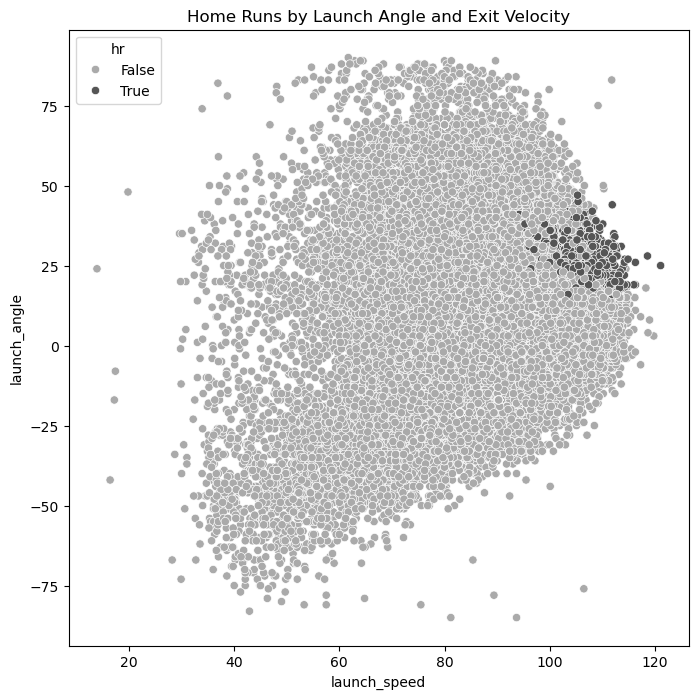

In [15]:
plt.figure(figsize=(8,8)) # example was just wrong
sns.despine(left=True, bottom=True)
sns.scatterplot(x="launch_speed", y = "launch_angle", 
                hue ="hr",
                palette='binary',
                data=data2)
plt.title("Home Runs by Launch Angle and Exit Velocity");
plt.show()

In [16]:
data2.groupby(pd.cut(data2.launch_speed, 6)).mean(numeric_only=True) # another example error lol

,release_speed,release_pos_x,release_pos_z,batter,pitcher,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,...,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,hr
launch_speed,,,,,,,,,,,,,,,,,,,,,
"(13.793, 31.767]",87.933333,-1.070952,5.817143,531710.142857,519580.0,<NA>,<NA>,<NA>,<NA>,9.47619,...,2.43381,0.701905,-0.091429,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.000000
"(31.767, 49.633]",87.86699,-0.846262,5.869235,531585.913835,531713.015777,<NA>,<NA>,<NA>,<NA>,9.057039,...,2.360376,0.532318,-0.062075,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.000000
"(49.633, 67.5]",88.049904,-0.867298,5.868271,525672.636364,527493.190141,<NA>,<NA>,<NA>,<NA>,8.611396,...,2.334457,0.483186,-0.053606,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.000000
"(67.5, 85.367]",88.28464,-0.906213,5.87684,526761.861113,530083.18921,<NA>,<NA>,<NA>,<NA>,7.594783,...,2.267695,0.511672,-0.120121,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.000000
"(85.367, 103.233]",88.978009,-0.969557,5.888883,524363.475547,531396.542639,<NA>,<NA>,<NA>,<NA>,6.466011,...,2.140411,0.567421,-0.107244,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.051757
"(103.233, 121.1]",89.733368,-0.929528,5.905656,528890.478618,532557.203076,<NA>,<NA>,<NA>,<NA>,6.046345,...,2.002361,0.672128,-0.072621,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.232989


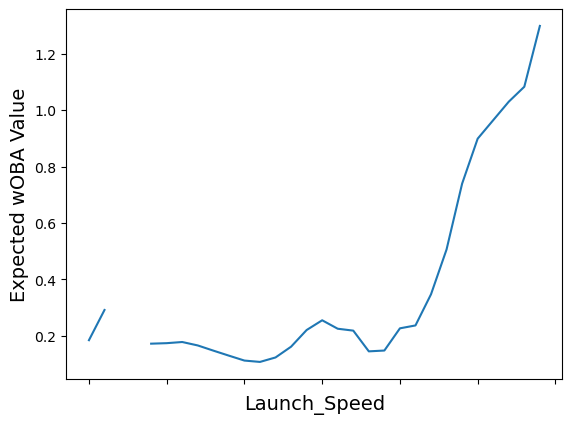

In [17]:
groups = data2.groupby(pd.cut(data2.launch_speed, 30)) # 30 buckets of launch speeds? 
ax = groups['estimated_woba_using_speedangle'].mean().plot() # awful plot format; also data trend is different than example early
ax.set_xlabel('Launch_Speed', fontsize=14)
ax.set_xticklabels([]) # does not match the example plot automatically with zero labels
ax.set_ylabel('Expected wOBA Value', fontsize=14);
plt.show()

# Playing around with Pitch Data
2017 is first year fo arsenal stats

In [ ]:
from pybaseball import statcast_pitcher_arsenal_stats

In [31]:
pitch2017 = statcast_pitcher_arsenal_stats(2017, minPA=100)
print(pitch2017.shape)

(616, 20)


In [29]:
pitch2021 = statcast_pitcher_arsenal_stats(2021, minPA=100)
print(pitch2021.shape)

(601, 20)


In [30]:
pitch2024= statcast_pitcher_arsenal_stats(2024, minPA=100)
print(pitch2024.shape)

(580, 20)


In [33]:
pitch2017.head()

,"last_name, first_name",player_id,team_name_alt,pitch_type,pitch_name,run_value_per_100,run_value,pitches,pitch_usage,pa,ba,slg,woba,whiff_percent,k_percent,put_away,est_ba,est_slg,est_woba,hard_hit_percent
0,"Dickey, R.A.",285079,ATL,KN,Knuckleball,-0.7,-16,2329,79.7,629,0.277,0.461,0.349,22.9,18.3,17.6,0.249,0.389,0.305,29.8
1,"Gausman, Kevin",592332,BAL,FF,4-Seam Fastball,-0.1,-1,2146,63.9,535,0.306,0.492,0.383,17.8,17.0,15.3,0.301,0.513,0.382,38.7
2,"Archer, Chris",502042,TB,SL,Slider,1.1,16,1512,44.4,487,0.214,0.347,0.275,37.1,37.2,28.6,0.196,0.314,0.247,32.6
3,"Stroman, Marcus",573186,TOR,SI,Sinker,0.7,12,1791,57.0,484,0.304,0.425,0.365,13.6,8.1,14.0,0.306,0.443,0.360,42.4
4,"Verlander, Justin",434378,HOU,FF,4-Seam Fastball,1.6,32,2036,57.7,437,0.206,0.311,0.281,20.1,23.6,17.7,0.253,0.446,0.342,41.9


In [51]:
pitch2017.describe()

,player_id,run_value_per_100,run_value,pitches,pitch_usage,pa,ba,slg,woba,whiff_percent,k_percent,put_away,est_ba,est_slg,est_woba,hard_hit_percent
count,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,531491.418831,0.212175,1.433442,678.043831,38.122890,176.586039,0.252091,0.418450,0.330234,23.977597,22.541071,19.048052,0.246836,0.411119,0.316195,33.610552
std,75442.864962,1.240744,8.148148,304.842681,16.887201,77.020929,0.057570,0.108648,0.068897,10.579844,11.011145,5.639007,0.051397,0.103421,0.064827,7.741988
min,112526.000000,-3.400000,-27.000000,302.000000,10.200000,100.000000,0.094000,0.128000,0.120000,5.600000,3.200000,4.900000,0.105000,0.145000,0.136000,7.600000
25%,468504.000000,-0.600000,-4.000000,469.500000,23.675000,121.750000,0.213000,0.338000,0.282000,15.500000,13.600000,15.200000,0.210000,0.343000,0.272750,28.600000
50%,542881.000000,0.200000,1.000000,586.000000,35.400000,152.000000,0.251500,0.422000,0.336000,21.900000,20.500000,18.500000,0.253000,0.414500,0.322000,34.050000
75%,594808.500000,1.100000,7.000000,790.750000,50.475000,203.250000,0.294000,0.491000,0.381000,31.725000,28.700000,22.225000,0.283000,0.482250,0.364000,38.900000
max,664641.000000,4.700000,39.000000,2329.000000,92.300000,629.000000,0.432000,0.717000,0.515000,59.200000,59.500000,40.100000,0.378000,0.729000,0.484000,57.000000


In [50]:
group17 = pitch2017.groupby('player_id', as_index=False).agg(list)
print(group17.shape)
group17.head()

(343, 20)


,player_id,"last_name, first_name",team_name_alt,pitch_type,pitch_name,run_value_per_100,run_value,pitches,pitch_usage,pa,ba,slg,woba,whiff_percent,k_percent,put_away,est_ba,est_slg,est_woba,hard_hit_percent
0,112526,"[Colon, Bartolo, Colon, Bartolo]","[MIN, MIN]","[SI, FF]","[Sinker, 4-Seam Fastball]","[-1.3, -2.3]","[-18, -10]","[1435, 450]","[62.8, 19.7]","[419, 112]","[0.346, 0.33]","[0.571, 0.632]","[0.422, 0.415]","[8.0, 15.2]","[11.9, 17.0]","[16.1, 11.9]","[0.295, 0.294]","[0.506, 0.575]","[0.358, 0.385]","[36.3, 50.0]"
1,276351,"[Grilli, Jason]",[TEX],[FF],[4-Seam Fastball],[-1.5],[-7],[485],[60.6],[116],[0.294],[0.569],[0.416],[26.1],[26.7],[18.0],[0.296],[0.513],[0.385],[28.2]
2,279571,"[Belisle, Matt]",[MIN],[FF],[4-Seam Fastball],[0.6],[3],[430],[45.9],[107],[0.231],[0.385],[0.315],[20.7],[22.4],[18.6],[0.233],[0.427],[0.327],[34.3]
3,282332,"[Sabathia, CC, Sabathia, CC, Sabathia, CC]","[NYY, NYY, NYY]","[FC, SL, SI]","[Cutter, Slider, Sinker]","[0.8, 1.2, -0.5]","[6, 9, -3]","[706, 726, 534]","[30.2, 31.0, 22.8]","[202, 189, 143]","[0.239, 0.185, 0.346]","[0.408, 0.295, 0.528]","[0.312, 0.245, 0.411]","[17.1, 25.2, 13.6]","[15.8, 35.4, 4.9]","[17.0, 20.6, 9.9]","[0.271, 0.18, 0.334]","[0.435, 0.262, 0.479]","[0.333, 0.233, 0.384]","[29.4, 25.5, 34.7]"
4,285079,"[Dickey, R.A., Dickey, R.A.]","[ATL, ATL]","[KN, FF]","[Knuckleball, 4-Seam Fastball]","[-0.7, 1.9]","[-16, 9]","[2329, 488]","[79.7, 16.7]","[629, 140]","[0.277, 0.25]","[0.461, 0.429]","[0.349, 0.364]","[22.9, 9.6]","[18.3, 10.0]","[17.6, 15.9]","[0.249, 0.299]","[0.389, 0.443]","[0.305, 0.382]","[29.8, 39.2]"


In [52]:
group17.describe()

,player_id
count,343.000000
mean,535134.014577
std,74092.969169
min,112526.000000
25%,483158.500000
50%,543144.000000
75%,595959.500000
max,664641.000000


# Hockey
## Interests: 
- Draft
- Player/Puck Tracking
### Data
Data from moneypuck CSV
Data from webscraping

# NFL
## Interests: 
- Draft
- Player Tracking
- Simulation/visuals

### Data:
Data from big data bowls 

# NBA
## Interests: 
- Draft
- Shooting
- visualizations
### Data:
Data from nba_api

# F1
## Interests:
- Telemetry
- Track visualizations
- Dashboard/tracking
### Data:
data from FastF1 api